In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import nbinom
from scipy.optimize import brentq

#### **Probabilidad de ruina en tiempo discreto**

El capital al final del periodo n es U_n = u + n − (S_1 + … + S_n), con prima de 1 por periodo, y hay ruina cuando U_n ≤ 0. Los siniestros agregados por periodo son S = 0 con probabilidad 2/3 y S = 2 con probabilidad 1/3. Se calcula la probabilidad de ruina ψ(u), el coeficiente de ajuste R, la cota de Lundberg y la severidad de la ruina φ(u, z).

In [3]:
# Distribución de S
u_max = 10
x_max = 200

f = np.zeros(x_max + 1)
f[0] = 2/3
f[2] = 1/3

F = np.cumsum(f)
F_bar = 1 - F
E_S = np.sum(np.arange(x_max + 1) * f)
print("E[S] =", E_S)

# Probabilidad de ruina ψ(u)
psi = np.zeros(u_max + 1)
psi[0] = E_S

for u in range(1, u_max + 1):
    suma_recursiva = sum(psi[u - y] * F_bar[y] for y in range(1, u))
    cola_infinita = E_S - np.sum(F_bar[:u])
    psi[u] = (suma_recursiva + cola_infinita) / (1 - F_bar[0])

resultados = pd.DataFrame({
    'Capital (u)': range(u_max + 1),
    'ψ(u)': psi
})

print("\nResultados ψ(u)")
print(resultados.to_string(index=False))

E[S] = 0.6666666666666666

Resultados ψ(u)
 Capital (u)     ψ(u)
           0 0.666667
           1 0.500000
           2 0.250000
           3 0.125000
           4 0.062500
           5 0.031250
           6 0.015625
           7 0.007812
           8 0.003906
           9 0.001953
          10 0.000977


In [4]:
# Coeficiente de ajuste: M_S(R) = e^R
def coeficiente(R):
    M_S = (2/3) + (1/3) * np.exp(2*R)
    return M_S - np.exp(R)

R_ajuste = brentq(coeficiente, 1e-6, 5)
print("R =", R_ajuste)

# Comparación con la cota de Lundberg
cota_lundberg = np.exp(-R_ajuste * np.arange(u_max + 1))

tabla_comparativa = pd.DataFrame({
    'Capital (u)': range(u_max + 1),
    'ψ(u)': psi,
    'Cota Lundberg exp(-Ru)': cota_lundberg
})

# Tolerancia numérica: para u ≥ 1, ψ(u) y la cota son iguales
tabla_comparativa['¿Se cumple ψ <= Cota?'] = (
    tabla_comparativa['ψ(u)'] <= tabla_comparativa['Cota Lundberg exp(-Ru)'] + 1e-12
)

print("\nComparación con Lundberg")
print(tabla_comparativa.to_string(index=False))

R = 0.6931471805599451

Comparación con Lundberg
 Capital (u)     ψ(u)  Cota Lundberg exp(-Ru)  ¿Se cumple ψ <= Cota?
           0 0.666667                1.000000                   True
           1 0.500000                0.500000                   True
           2 0.250000                0.250000                   True
           3 0.125000                0.125000                   True
           4 0.062500                0.062500                   True
           5 0.031250                0.031250                   True
           6 0.015625                0.015625                   True
           7 0.007812                0.007813                   True
           8 0.003906                0.003906                   True
           9 0.001953                0.001953                   True
          10 0.000977                0.000977                   True


In [5]:
# Severidad de la ruina φ(u, z)
u_eval = 10
z_eval = 10
u_limite = 25
iteraciones = 500

phi_z = np.zeros((u_limite + 1, z_eval + 1))

for n in range(iteraciones):
    phi_nuevo = np.zeros_like(phi_z)
    for u in range(u_limite):
        for z in range(z_eval + 1):
            # Ruina inmediata: S = u + 1 + z
            ruina_inm = 1/3 if (u + 1 + z) == 2 else 0.0

            # Ruina futura
            futuro_S0 = (2/3) * phi_z[u + 1, z]
            futuro_S2 = (1/3) * phi_z[u - 1, z] if u >= 2 else 0.0

            phi_nuevo[u, z] = ruina_inm + futuro_S0 + futuro_S2
    phi_z = phi_nuevo

df_severidad = pd.DataFrame(
    phi_z[:u_eval + 1, :z_eval + 1],
    index=[f"u={u}" for u in range(u_eval + 1)],
    columns=[f"z={z}" for z in range(z_eval + 1)]
)

print("Resultados φ(u, z)")
print(df_severidad.round(5).to_string())

Resultados φ(u, z)
          z=0      z=1  z=2  z=3  z=4  z=5  z=6  z=7  z=8  z=9  z=10
u=0   0.33333  0.33333  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0
u=1   0.50000  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0
u=2   0.25000  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0
u=3   0.12500  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0
u=4   0.06250  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0
u=5   0.03125  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0
u=6   0.01562  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0
u=7   0.00781  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0
u=8   0.00391  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0
u=9   0.00195  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0
u=10  0.00098  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0


#### **Probabilidad de ruina con siniestros binomial negativa**

Mismo modelo en tiempo discreto, con siniestros agregados por periodo f_S(0) = 0.8 + 0.2·g(0) y f_S(x) = 0.2·g(x) para x ≥ 1, donde g es una binomial negativa con r = 5 y q = 0.62. Se calcula ψ(u), la probabilidad de ruina en tiempo finito ψ(u, n), el coeficiente de ajuste con la cota de Lundberg y la severidad de la ruina φ(u, z).

In [6]:
# Parámetros
q = 0.62
r = 5
u_max = 25
n_max = 25
x_max = 300

# Distribución de S
x = np.arange(x_max + 1)
f = 0.2 * nbinom.pmf(x, r, q)
f[0] += 0.8

F = np.cumsum(f)
F_bar = 1 - F
E_S = np.sum(x * f)
print("E[S] =", E_S)

# Probabilidad de ruina ψ(u)
psi = np.zeros(u_max + 1)
psi[0] = E_S

for u in range(1, u_max + 1):
    suma_recursiva = sum(psi[u - y] * F_bar[y] for y in range(1, u))
    cola_infinita = E_S - np.sum(F_bar[:u])
    psi[u] = (suma_recursiva + cola_infinita) / (1 - F_bar[0])

resultados = pd.DataFrame({
    'Capital (u)': range(u_max + 1),
    'Probabilidad Ruina ψ(u)': psi
})

print(resultados.to_string(index=False))

E[S] = 0.6129032258064517
 Capital (u)  Probabilidad Ruina ψ(u)
           0                 0.612903
           1                 0.526963
           2                 0.442067
           3                 0.364876
           4                 0.298291
           5                 0.242608
           6                 0.196830
           7                 0.159517
           8                 0.129224
           9                 0.104672
          10                 0.084782
          11                 0.068673
          12                 0.055625
          13                 0.045057
          14                 0.036497
          15                 0.029563
          16                 0.023946
          17                 0.019397
          18                 0.015712
          19                 0.012727
          20                 0.010309
          21                 0.008350
          22                 0.006764
          23                 0.005479
          24            

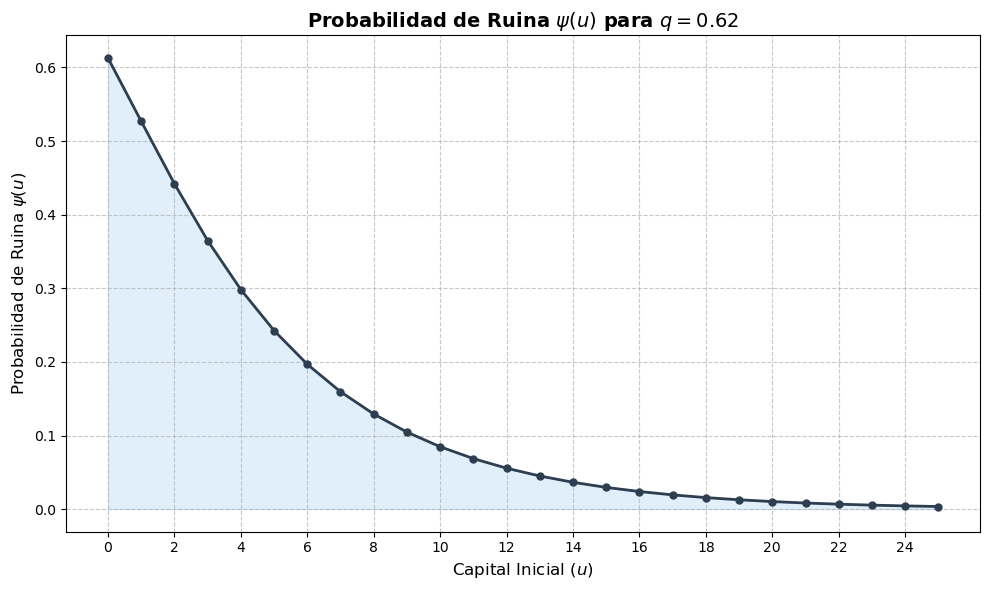

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(resultados['Capital (u)'], resultados['Probabilidad Ruina ψ(u)'],
         marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=5)
plt.fill_between(resultados['Capital (u)'], resultados['Probabilidad Ruina ψ(u)'],
                 color='#3498db', alpha=0.15)
plt.title(f'Probabilidad de Ruina $\\psi(u)$ para $q={q}$', fontsize=14, fontweight='bold')
plt.xlabel('Capital Inicial ($u$)', fontsize=12)
plt.ylabel('Probabilidad de Ruina $\\psi(u)$', fontsize=12)
plt.xticks(range(0, u_max + 1, 2))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
# Probabilidad de ruina en tiempo finito ψ(u, n)
u_limite = u_max + n_max
psi_n = np.zeros((u_limite + 1, n_max + 1))

for n in range(1, n_max + 1):
    for u in range(u_limite - n + 1):
        ruina_inmediata = F_bar[u]
        ruina_futura = np.sum(f[:u + 1] * psi_n[u + 1 - np.arange(u + 1), n - 1])
        psi_n[u, n] = ruina_inmediata + ruina_futura

resultados_n = pd.DataFrame(psi_n[:u_max + 1, :], columns=[f"n={n}" for n in range(n_max + 1)])
resultados_n.insert(0, 'Capital (u)', range(u_max + 1))

print("Resultados ψ(u, n)")
print(resultados_n[['Capital (u)', 'n=1', 'n=5', 'n=10', f'n={n_max}']].head(11).to_string(index=False))

Resultados ψ(u, n)
 Capital (u)      n=1      n=5     n=10     n=25
           0 0.181677 0.458887 0.534356 0.589196
           1 0.146864 0.367260 0.440552 0.499760
           2 0.107177 0.280063 0.350120 0.411972
           3 0.071988 0.205795 0.270696 0.332860
           4 0.045245 0.147115 0.205190 0.265412
           5 0.026952 0.103039 0.153341 0.209833
           6 0.015367 0.071052 0.113382 0.164947
           7 0.008449 0.048389 0.083129 0.129120
           8 0.004505 0.032608 0.060507 0.100727
           9 0.002341 0.021769 0.043750 0.078330
          10 0.001189 0.014406 0.031436 0.060729


In [9]:
# Coeficiente de ajuste
# M_S(R) solo existe para R < −ln(1 − q)
def coeficiente(R):
    M_NB = (q / (1 - (1 - q) * np.exp(R)))**r
    M_S = 0.8 + 0.2 * M_NB
    return M_S - np.exp(R)

R_ajuste = brentq(coeficiente, 1e-6, -np.log(1 - q) - 1e-6)
print("R =", R_ajuste)

# Comparación con la cota de Lundberg
cota_lundberg = np.exp(-R_ajuste * np.arange(u_max + 1))

tabla_comparativa = pd.DataFrame({
    'Capital (u)': range(u_max + 1),
    'Probabilidad ψ(u)': psi,
    'Cota Lundberg exp(-Ru)': cota_lundberg
})
tabla_comparativa['¿Se cumple ψ <= Cota?'] = (
    tabla_comparativa['Probabilidad ψ(u)'] <= tabla_comparativa['Cota Lundberg exp(-Ru)']
)

print("Comparación entre ψ(u) y Lundberg")
print(tabla_comparativa.head(10).to_string(index=False))

R = 0.2107011589837395
Comparación entre ψ(u) y Lundberg
 Capital (u)  Probabilidad ψ(u)  Cota Lundberg exp(-Ru)  ¿Se cumple ψ <= Cota?
           0           0.612903                1.000000                   True
           1           0.526963                0.810016                   True
           2           0.442067                0.656126                   True
           3           0.364876                0.531473                   True
           4           0.298291                0.430501                   True
           5           0.242608                0.348713                   True
           6           0.196830                0.282463                   True
           7           0.159517                0.228800                   True
           8           0.129224                0.185331                   True
           9           0.104672                0.150121                   True


In [10]:
# Severidad de la ruina φ(u, z)
u_eval = 10
z_eval = 10
u_limite = 25
iteraciones = 500

phi_z = np.zeros((u_limite + 1, z_eval + 1))

for n in range(iteraciones):
    phi_nuevo = np.zeros_like(phi_z)
    for u in range(u_limite):
        for z in range(z_eval + 1):
            ruina_inm = f[u + 1 + z]
            ruina_futura = np.sum(f[:u + 1] * phi_z[u + 1 - np.arange(u + 1), z])
            phi_nuevo[u, z] = ruina_inm + ruina_futura
    phi_z = phi_nuevo

df_severidad = pd.DataFrame(
    phi_z[:u_eval + 1, :z_eval + 1],
    index=[f"u={u}" for u in range(u_eval + 1)],
    columns=[f"z={z}" for z in range(z_eval + 1)]
)

print("Resultados φ(u, z)")
print(df_severidad.round(5).to_string())

Resultados φ(u, z)
          z=0      z=1      z=2      z=3      z=4      z=5      z=6      z=7      z=8      z=9     z=10
u=0   0.18112  0.14651  0.10696  0.07187  0.04518  0.02691  0.01535  0.00844  0.00450  0.00234  0.00119
u=1   0.17878  0.13054  0.08771  0.05514  0.03285  0.01873  0.01030  0.00549  0.00285  0.00145  0.00072
u=2   0.16237  0.11097  0.07077  0.04268  0.02459  0.01364  0.00733  0.00383  0.00196  0.00098  0.00048
u=3   0.13984  0.09187  0.05686  0.03351  0.01896  0.01036  0.00550  0.00285  0.00144  0.00072  0.00035
u=4   0.11670  0.07501  0.04571  0.02663  0.01493  0.00811  0.00428  0.00221  0.00112  0.00055  0.00027
u=5   0.09568  0.06082  0.03679  0.02133  0.01192  0.00646  0.00340  0.00175  0.00088  0.00044  0.00021
u=6   0.07772  0.04915  0.02964  0.01715  0.00957  0.00518  0.00273  0.00141  0.00071  0.00035  0.00017
u=7   0.06282  0.03964  0.02388  0.01381  0.00771  0.00417  0.00220  0.00113  0.00057  0.00028  0.00014
u=8   0.05064  0.03193  0.01923  0.01112  0.0

#### **Simulación Monte Carlo del modelo de Cramér-Lundberg**

U(t) = u + c·t − (Y_1 + … + Y_N(t)), con prima c = 5, llegadas Poisson con λ = 2 y montos Y ~ Gamma(α = 3, β = 4). Se estima la probabilidad de ruina en horizonte finito con 100,000 trayectorias.

In [11]:
def simular_ruina_finita(capitales, t_max, c=5, lam=2, alpha=3, beta=4, sims=100000, max_siniestros=100):
    np.random.seed(42)

    # Tiempos de llegada
    T = np.random.exponential(scale=1/lam, size=(sims, max_siniestros))
    tau = np.cumsum(T, axis=1)

    # Montos de los siniestros
    Y = np.random.gamma(shape=alpha, scale=1/beta, size=(sims, max_siniestros))
    cambio_neto = c * tau - np.cumsum(Y, axis=1)

    resultados = {}
    for u in capitales:
        hubo_ruina = np.any((u + cambio_neto < 0) & (tau <= t_max), axis=1)
        resultados[f"u={u}"] = np.mean(hubo_ruina)
    return resultados

capitales_evaluar = [1, 5, 10]

for t_max in [10, 1]:
    print(f"Probabilidades de ruina en horizonte finito (t <= {t_max}):")
    for capital, prob in simular_ruina_finita(capitales_evaluar, t_max).items():
        print(f"  Capital {capital} -> Probabilidad: {prob}")

Probabilidades de ruina en horizonte finito (t <= 10):
  Capital u=1 -> Probabilidad: 0.0739
  Capital u=5 -> Probabilidad: 7e-05
  Capital u=10 -> Probabilidad: 0.0
Probabilidades de ruina en horizonte finito (t <= 1):
  Capital u=1 -> Probabilidad: 0.07266
  Capital u=5 -> Probabilidad: 7e-05
  Capital u=10 -> Probabilidad: 0.0
